In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from imblearn.ensemble import BalancedRandomForestClassifier, BalancedBaggingClassifier

In [2]:
parent_dir = os.path.dirname(os.getcwd())
data = pd.read_csv(os.path.join(parent_dir, 'final_output_with_2012.csv'))
data

,hours,active_hours,mmsi_count,year,source_file,event_id,date,country,region,Location,...,IncomeClass_WGI,VAGov_WGI,PVGov_WGI,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF
0,NaN,NaN,NaN,1990,HOA_FDE_All_Final,e3154,7/18/1990,Somalia,Horn of Africa,Maydh Island,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.460
1,NaN,NaN,NaN,1990,HOA_FDE_All_Final,e2000,9/29/1990,Kenya,Horn of Africa,Kenyan Lake Victoria Waters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.051
2,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e4086,4/20/1991,Yemen,Horn of Africa,Yemeni waters,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,30000.0,NaN
3,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e2003,6/1/1991,Kenya,Horn of Africa,Kenya,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2700000.0,0.346
4,NaN,NaN,NaN,1991,HOA_FDE_All_Final,e5006,6/1/1991,Yemen,Horn of Africa,yemeni coast,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,30000.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1051,6.830387e+06,5.390027e+06,1382.0,2023,Oceania_No_AUS_NZL_Final,52223449994,10/31/2023,Samoa,Oceania,Fagaalu Marine Protected Area.,...,Upper middle income,75.617571,87.135763,59.498392,52.185701,75.088207,64.429976,0.0,0.0,0.915
1052,6.582953e+06,5.535860e+06,1115.0,2019,Oceania_No_AUS_NZL_Final,53225464993,3/1/2024,Papua New Guinea,Oceania,"New Ireland Province, Papua New Guinea, specif...",...,Lower middle income,55.544024,52.242829,37.209910,46.850980,44.674778,27.873945,2.0,350.0,0.575
1053,6.044811e+06,4.733928e+06,1289.0,2024,Oceania_No_AUS_NZL_Final,54214315906,7/4/2024,French Polynesia,Oceania,"Tautira municipality, French Polynesia.",...,High income,72.191156,83.494244,NaN,NaN,74.471348,43.633725,0.0,0.0,0.895
1054,6.044811e+06,4.733928e+06,1289.0,2024,Oceania_No_AUS_NZL_Final,54501479045,8/6/2024,American Samoa,Oceania,"Vaitogi, American Samoa, specifically along th...",...,High income,73.136662,87.298125,66.261470,61.041225,75.665539,71.663617,0.0,0.0,1.588


In [17]:
print(data.shape)
df = data.loc[data['year'] >= 2012].copy()
#drop columns that are not needed for the model
df.drop(columns=['year','source_file','event_id','date','country','region','Location','latitude','longitude','loc_accuracy','Actor1','Actor2','ViolenceScore_Explanation','Explanation','Summary','Disputed','ForcedLabor','ECO_OHI','hours'], inplace=True)
#drop rows with too many null values
#show the number of null values in each column
display(round(df.isnull().sum()/len(df)*100, 2))
# drop columns with more than 25% null values
df.drop(columns=['IncrPressure','LE_OHI','LIV_OHI'],inplace=True) #,'TR_OHI','GEGov_WGI','RGGov_WGI','NP_OHI','IncomeClass_WGI'
df.dropna(inplace=True)
print(df.shape)

(1056, 66)


active_hours         0.00
mmsi_count           0.00
WeakGov              0.00
FishPop              0.00
EcoChngeOther        0.00
GroundsLim           0.00
ForeignFisher        0.00
IllegalFishing       0.00
IncrEfficiency       0.00
IncrPressure        32.63
OpsScales            0.00
Markets              0.00
Poverty              0.00
FoodInsecurity       0.00
Marginalization      0.00
StratLoc             0.00
MaritimeCrime        0.00
violence_score       0.00
WB_GDP               5.36
AO_OHI               2.33
BD_OHI               1.86
CP_OHI               1.86
CS_OHI               3.03
CW_OHI               1.86
FIS_OHI              1.86
FOO_OHI              1.86
HAB_OHI              1.86
ICO_OHI              1.86
Total_OHI            1.86
LE_OHI              34.97
LIV_OHI             34.97
LSP_OHI              1.86
MAR_OHI              2.56
NP_OHI              16.55
SP_OHI               1.86
SPP_OHI              1.86
TR_OHI              22.61
IncomeClass_WGI     16.55
VAGov_WGI   

(238, 44)


In [18]:
#scale data and handle categorical variables
df_x = df.drop(columns=['violence_score'])
df_y = df['violence_score']
display(df_x.head())

scaler = StandardScaler()
df_x_scaled = df_x.copy().drop(columns=['IncomeClass_WGI'])
df_x_scaled = pd.DataFrame(scaler.fit_transform(df_x_scaled), columns=df_x_scaled.columns)
income_class_dummies = pd.get_dummies(df_x['IncomeClass_WGI'],drop_first=True).reset_index(drop=True)
df_x_scaled = pd.concat([df_x_scaled, income_class_dummies], axis=1)

# df_x_scaled = pd.DataFrame(scaler.fit_transform(df_x), columns=df_x.columns)
df_x_scaled

,active_hours,mmsi_count,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,...,IncomeClass_WGI,VAGov_WGI,PVGov_WGI,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF
630,7.214843e+04,17.0,0,1,1,1,0,1,1,0,...,Lower middle income,54.306201,63.766022,39.648453,47.215457,49.469864,35.336614,1.0,0.0,0.891
631,8.568749e+05,204.0,0,1,0,0,0,1,0,0,...,Upper middle income,72.080065,92.665226,27.341918,38.144135,67.741392,44.285959,0.0,0.0,0.687
632,7.214843e+04,17.0,0,0,0,1,0,0,0,0,...,Lower middle income,50.646769,40.388860,42.228777,46.784585,43.429425,28.120388,1.0,280670.0,0.981
633,1.004043e+07,5478.0,0,0,0,0,0,0,0,0,...,High income,82.176045,84.569623,88.981136,82.123009,84.525671,85.114238,3.0,1500.0,2.161
634,1.004043e+07,5478.0,0,0,1,0,0,0,0,0,...,High income,78.970213,76.497769,81.067472,77.609506,80.789015,73.421930,25.0,93551.0,1.458


,active_hours,mmsi_count,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,...,PVGov_WGI,GEGov_WGI,RGGov_WGI,RLGov_WGI,CCGov_WGI,ClimDisaster_IMF,PplAffect_IMF,TempChange_IMF,Lower middle income,Upper middle income
0,-0.795675,-0.708693,-0.600000,0.927025,2.043016,0.843937,-0.619452,1.034198,1.891276,-0.24037,...,0.087929,-0.731457,-0.655101,-0.616601,-0.628485,-0.583811,-0.129468,-0.321265,True,False
1,-0.709916,-0.672211,-0.600000,0.927025,-0.489473,-1.184922,-0.619452,1.034198,-0.528744,-0.24037,...,2.152558,-1.387234,-1.307754,0.568324,-0.170454,-0.669528,-0.129468,-0.766950,False,True
2,-0.795675,-0.708693,-0.600000,-1.078720,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,-0.24037,...,-1.582192,-0.593959,-0.686101,-1.008328,-0.997814,-0.583811,-0.093345,-0.124640,True,False
3,0.293713,0.356704,-0.600000,-1.078720,-0.489473,-1.184922,-0.619452,-0.966933,-0.528744,-0.24037,...,1.574188,1.897329,1.856389,1.656800,1.919154,-0.412377,-0.129275,2.453340,False,False
4,0.293713,0.356704,-0.600000,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,-0.528744,-0.24037,...,0.997515,1.475634,1.531656,1.414474,1.320737,1.473394,-0.117428,0.917476,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233,1.581643,1.849938,-0.600000,0.927025,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,-0.24037,...,0.004290,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False
234,-0.214508,-0.442392,-0.600000,-1.078720,-0.489473,0.843937,1.614330,1.034198,-0.528744,-0.24037,...,-0.407789,-1.231681,-0.911582,-0.700636,-0.611267,-0.669528,-0.129468,-0.699223,True,False
235,1.581643,1.849938,-0.600000,0.927025,-0.489473,0.843937,-0.619452,-0.966933,-0.528744,-0.24037,...,0.004290,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False
236,1.581643,1.849938,1.666667,-1.078720,2.043016,-1.184922,-0.619452,-0.966933,1.891276,-0.24037,...,0.004290,1.299157,1.518507,0.941703,1.250296,1.473394,-0.125860,0.351631,False,False


In [ ]:
#check correlations in x variables
corr_matrix_x = df_x_scaled.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix_x, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Correlation Matrix')
plt.xticks(range(len(df_x_scaled.columns)), df_x_scaled.columns, rotation=90)
plt.yticks(range(len(df_x_scaled.columns)), df_x_scaled.columns)
plt.show()

In [19]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_x_scaled, df_y, test_size=0.2, random_state=117)


In [20]:
#random forest model
rf = RandomForestClassifier(random_state=117,
                            n_estimators=100,                            
                            class_weight='balanced',
                            n_jobs=-1)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

           1       0.73      0.64      0.68        25
           2       0.50      0.53      0.51        17
           3       0.38      0.50      0.43         6

    accuracy                           0.58        48
   macro avg       0.53      0.56      0.54        48
weighted avg       0.60      0.58      0.59        48



In [21]:
#random forest model with grid search for hyperparameter tuning
grid_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2,3,4,5],
    'min_samples_leaf': [1,2,3,4],
    'max_features': ['sqrt', 'log2']
}


rf_grid = GridSearchCV(RandomForestClassifier(random_state=117,
                                 class_weight='balanced'),
                                 grid_params,
                                 scoring='f1_macro',
                                 n_jobs=-1)

rf_grid.fit(X_train, y_train)
y_pred_grid = rf_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))
print("Best Parameters:", rf_grid.best_params_)


Accuracy: 0.5833333333333334
              precision    recall  f1-score   support

           1       0.75      0.60      0.67        25
           2       0.47      0.53      0.50        17
           3       0.44      0.67      0.53         6

    accuracy                           0.58        48
   macro avg       0.56      0.60      0.57        48
weighted avg       0.61      0.58      0.59        48

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


                Feature  Importance
25              ICO_OHI    0.050113
1            mmsi_count    0.049666
7        IllegalFishing    0.048868
35            GEGov_WGI    0.048610
26            Total_OHI    0.040230
0          active_hours    0.036993
38            CCGov_WGI    0.034773
16               WB_GDP    0.033264
3               FishPop    0.031279
32               TR_OHI    0.031241
21               CW_OHI    0.028401
37            RLGov_WGI    0.026533
6         ForeignFisher    0.026138
36            RGGov_WGI    0.025568
5            GroundsLim    0.025448
33            VAGov_WGI    0.024693
31              SPP_OHI    0.024657
34            PVGov_WGI    0.022963
41       TempChange_IMF    0.022709
4         EcoChngeOther    0.022679
42  Lower middle income    0.020748
17               AO_OHI    0.020498
22              FIS_OHI    0.020341
23              FOO_OHI    0.019349
30               SP_OHI    0.019251
39     ClimDisaster_IMF    0.018624
2               WeakGov    0

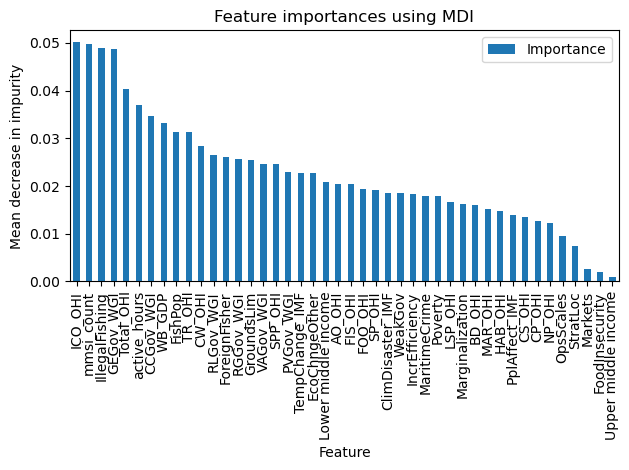

In [22]:
#get feature importances from the best model (GINI importance)
feature_importances = rf_grid.best_estimator_.feature_importances_
feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
print(feature_importances_df)

fig, ax = plt.subplots()
feature_importances_df.plot.bar(x='Feature', y='Importance', ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

                Feature  Importance
28              MAR_OHI    0.041667
29               NP_OHI    0.041667
32               TR_OHI    0.041667
23              FOO_OHI    0.041667
39     ClimDisaster_IMF    0.041667
14             StratLoc    0.020833
15        MaritimeCrime    0.020833
18               BD_OHI    0.020833
6         ForeignFisher    0.020833
38            CCGov_WGI    0.020833
37            RLGov_WGI    0.020833
30               SP_OHI    0.020833
20               CS_OHI    0.020833
22              FIS_OHI    0.020833
16               WB_GDP    0.020833
40        PplAffect_IMF    0.020833
36            RGGov_WGI    0.000000
35            GEGov_WGI    0.000000
33            VAGov_WGI    0.000000
9             OpsScales    0.000000
3               FishPop    0.000000
4         EcoChngeOther    0.000000
0          active_hours    0.000000
11              Poverty    0.000000
7        IllegalFishing    0.000000
5            GroundsLim    0.000000
10              Markets    0

<Axes: xlabel='Feature'>

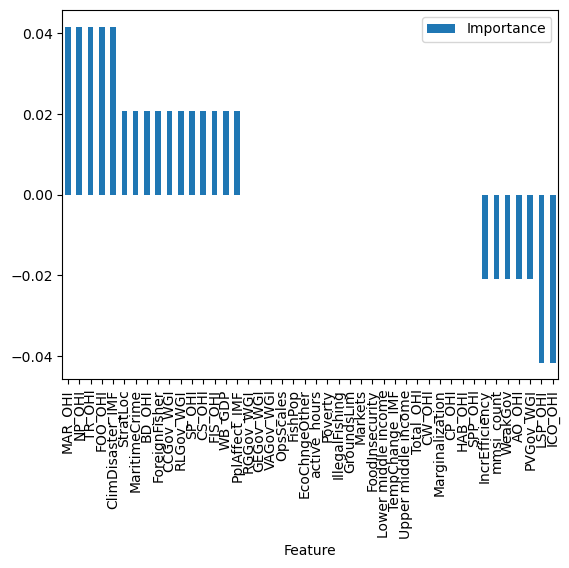

In [24]:
# calculate MDA
importances = []
initial_accuracy = accuracy_score(y_test, rf_grid.predict(X_test))
for i in range(X_test.shape[1]):
    X_test_permuted = X_test.copy()
    permuted_values = X_test_permuted.iloc[:, i].to_numpy().copy()
    np.random.shuffle(permuted_values)
    X_test_permuted.iloc[:, i] = permuted_values
    permuted_accuracy = accuracy_score(y_test, rf_grid.predict(X_test_permuted))
    importances.append(initial_accuracy - permuted_accuracy)

accuracy_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances})
accuracy_importances_df = accuracy_importances_df.sort_values(by='Importance', ascending=False)
print(accuracy_importances_df)

#plot
fig, ax = plt.subplots()
accuracy_importances_df.plot.bar(x='Feature', y='Importance', ax=ax)

                Feature  Importance
37            RLGov_WGI    0.042131
29               NP_OHI    0.037597
5            GroundsLim    0.036111
16               WB_GDP    0.035776
20               CS_OHI    0.033579
3               FishPop    0.032671
39     ClimDisaster_IMF    0.031095
19               CP_OHI    0.028985
40        PplAffect_IMF    0.028246
33            VAGov_WGI    0.027431
6         ForeignFisher    0.024179
18               BD_OHI    0.021338
21               CW_OHI    0.021249
15        MaritimeCrime    0.021051
34            PVGov_WGI    0.019838
7        IllegalFishing    0.019001
31              SPP_OHI    0.018326
22              FIS_OHI    0.017793
17               AO_OHI    0.015220
28              MAR_OHI    0.015108
38            CCGov_WGI    0.012148
42  Lower middle income    0.011258
35            GEGov_WGI    0.009966
1            mmsi_count    0.009626
23              FOO_OHI    0.004923
14             StratLoc    0.003975
10              Markets    0

<Axes: xlabel='Feature'>

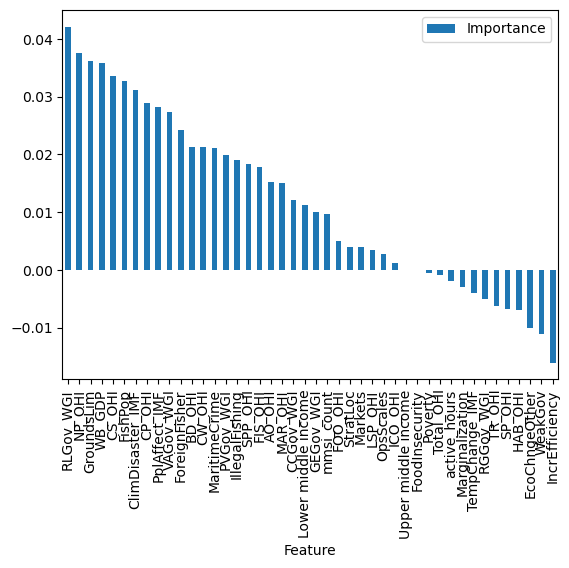

In [25]:
#permutation importance using sklearn's permutation_importance function
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(rf_grid, X_test, y_test, n_repeats=10, random_state=117,n_jobs=-1)
perm_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': perm_importance.importances_mean})
perm_importance_df = perm_importance_df.sort_values(by='Importance', ascending=False)
print(perm_importance_df)
#plot
fig, ax = plt.subplots()
perm_importance_df.plot.bar(x='Feature', y='Importance', ax=ax)


                Feature  Mean |SHAP Value|
22              FIS_OHI           0.052675
21               CW_OHI           0.039499
3               FishPop           0.037293
11              Poverty           0.028333
0          active_hours           0.025387
4         EcoChngeOther           0.020675
15        MaritimeCrime           0.019232
19               CP_OHI           0.018941
5            GroundsLim           0.017451
10              Markets           0.017249
16               WB_GDP           0.016922
18               BD_OHI           0.016149
1            mmsi_count           0.016119
12       FoodInsecurity           0.016042
13      Marginalization           0.015816
23              FOO_OHI           0.014053
9             OpsScales           0.013363
33            VAGov_WGI           0.012808
2               WeakGov           0.012643
41       TempChange_IMF           0.012231
34            PVGov_WGI           0.010877
8        IncrEfficiency           0.008211
40        P

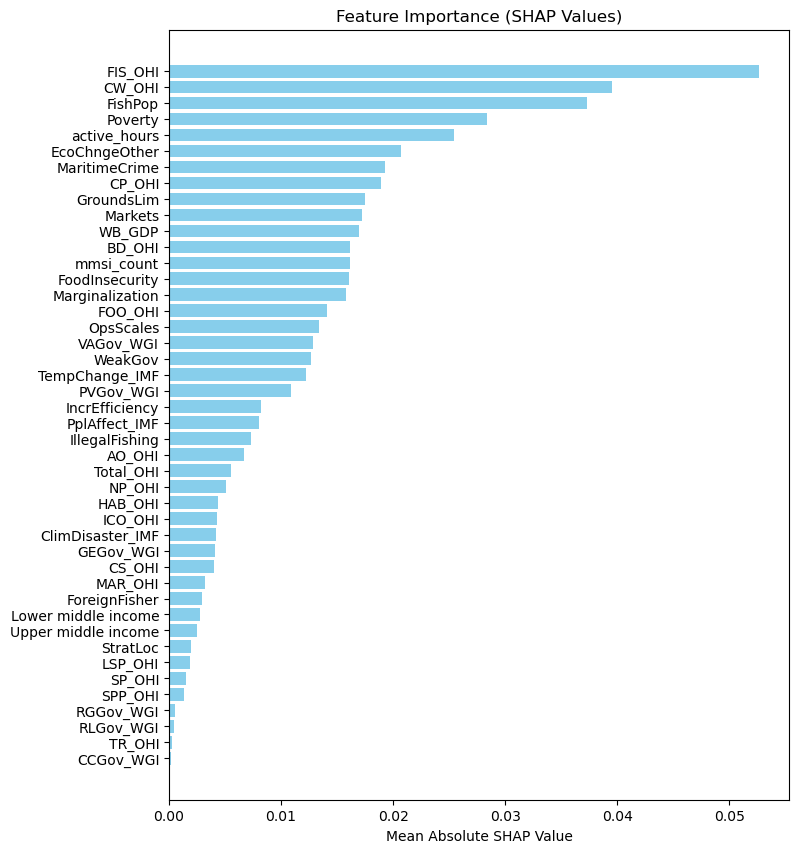

In [31]:
# calculate SHAP values
import shap
explainer = shap.TreeExplainer(rf_grid.best_estimator_)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_summary = np.mean(np.abs(np.stack(shap_values)), axis=(0, 1))
else:
    shap_summary = np.abs(shap_values).mean(axis=0)

shap_summary = shap_summary.flatten()
shap_summary = shap_summary[:len(df_x_scaled.columns)]  # Ensure the length matches the number of features
shap_summary_df = pd.DataFrame({
    'Feature': df_x_scaled.columns,
    'Mean |SHAP Value|': shap_summary
}).sort_values('Mean |SHAP Value|', ascending=False)

print(shap_summary_df)
plt.figure(figsize=(8, 10))
plt.barh(shap_summary_df['Feature'],
         shap_summary_df['Mean |SHAP Value|'], color='skyblue')
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Feature Importance (SHAP Values)')
plt.gca().invert_yaxis()
plt.show()

In [26]:
#balanced random forest to handle class imbalance
rf_balanced_grid = GridSearchCV(BalancedRandomForestClassifier(random_state=117, n_jobs=-1),
                                grid_params,
                                scoring='f1_macro',
                                n_jobs=-1)
rf_balanced_grid.fit(X_train, y_train)
y_pred_balanced = rf_balanced_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))
print("Best Parameters:", rf_balanced_grid.best_params_)



Accuracy: 0.5208333333333334
              precision    recall  f1-score   support

           1       0.77      0.40      0.53        25
           2       0.48      0.59      0.53        17
           3       0.36      0.83      0.50         6

    accuracy                           0.52        48
   macro avg       0.53      0.61      0.52        48
weighted avg       0.61      0.52      0.52        48

Best Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [32]:
#balanced bagging classifier to handle class imbalance
bagging_params = {
    'n_estimators': [100, 200, 300],
    'max_samples': [0.5, 0.75, 1.0],
    'max_features': [0.5, 0.75, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False]}

bagging_grid = GridSearchCV(BalancedBaggingClassifier(random_state=117),
                            bagging_params,
                            scoring='f1_macro',
                            n_jobs=-1)

bagging_grid.fit(X_train, y_train)
y_pred_bagging = bagging_grid.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print(classification_report(y_test, y_pred_bagging))
print("Best Parameters:", bagging_grid.best_params_)

#bagging without grid search
bagging = BalancedBaggingClassifier(random_state=117,
                                     n_estimators=200,
                                     max_samples=0.75,
                                     max_features=0.75,
                                     bootstrap=True,
                                     bootstrap_features=True)
bagging.fit(X_train, y_train)
y_pred_bagging_no_grid = bagging.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_bagging_no_grid))
print(classification_report(y_test, y_pred_bagging_no_grid))


Accuracy: 0.5
              precision    recall  f1-score   support

           1       0.77      0.40      0.53        25
           2       0.50      0.53      0.51        17
           3       0.29      0.83      0.43         6

    accuracy                           0.50        48
   macro avg       0.52      0.59      0.49        48
weighted avg       0.61      0.50      0.51        48

Best Parameters: {'bootstrap': False, 'bootstrap_features': True, 'max_features': 0.75, 'max_samples': 1.0, 'n_estimators': 100}
Accuracy: 0.5
              precision    recall  f1-score   support

           1       0.71      0.40      0.51        25
           2       0.45      0.53      0.49        17
           3       0.36      0.83      0.50         6

    accuracy                           0.50        48
   macro avg       0.51      0.59      0.50        48
weighted avg       0.58      0.50      0.50        48

